# Texture-Based CBIR Using GLCM

This notebook implements a Content-Based Image Retrieval (CBIR) system
using texture features extracted by Gray Level Co-occurrence Matrix (GLCM).

Steps:
- Load processed dataset
- Convert image to grayscale
- Extract GLCM texture features
- Build feature database
- Compare query image with dataset images
- Retrieve top similar images

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
DATASET_PATH = "processed_dataset"

categories = sorted(os.listdir(DATASET_PATH))
print("Categories:", categories)

Categories: ['ambulance', 'bicycle', 'bus', 'car', 'fire_truck', 'motorcycle', 'tractor', 'truck', 'van']


## GLCM Feature Extraction

GLCM describes how often pairs of pixel values occur in an image.
From the GLCM, several texture properties can be extracted.

In this notebook, the following properties are used:
- contrast
- correlation
- energy
- homogeneity

In [3]:
def extract_glcm_features(image_path, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256):
    """
    Extract GLCM texture features from an image.

    Parameters:
        image_path : str
            Path to input image
        distances : list
            Pixel pair distance
        angles : list
            Angle in radians
        levels : int
            Number of gray levels

    Returns:
        feature_vector : numpy array
            GLCM texture feature vector
    """
    
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    glcm = graycomatrix(
        image,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast').flatten()
    correlation = graycoprops(glcm, 'correlation').flatten()
    energy = graycoprops(glcm, 'energy').flatten()
    homogeneity = graycoprops(glcm, 'homogeneity').flatten()

    feature_vector = np.hstack([contrast, correlation, energy, homogeneity])

    return feature_vector

## Build Feature Database

For each image in the dataset:
- extract GLCM texture features
- store image path
- store category label

In [4]:
image_paths = []
image_labels = []
features = []

for category in categories:
    category_path = os.path.join(DATASET_PATH, category)

    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        glcm_feature = extract_glcm_features(img_path)

        if glcm_feature is not None:
            image_paths.append(img_path)
            image_labels.append(category)
            features.append(glcm_feature)

features = np.array(features)

print("Total images indexed:", len(image_paths))
print("Feature shape:", features.shape)

Total images indexed: 1800
Feature shape: (1800, 16)


## Similarity Function

We compare the query image with all dataset images using cosine similarity.
Higher score means more similar.

In [5]:
def retrieve_similar_images(query_image_path, top_k=5):
    """
    Retrieve top_k similar images using GLCM texture features.
    """
    query_feature = extract_glcm_features(query_image_path)

    if query_feature is None:
        print("Query image could not be loaded.")
        return []

    similarities = cosine_similarity([query_feature], features)[0]

    # Sort from highest similarity to lowest
    sorted_indices = np.argsort(similarities)[::-1]

    results = []
    for idx in sorted_indices:
        # Skip the query image itself
        if image_paths[idx] == query_image_path:
            continue

        results.append({
            "image_path": image_paths[idx],
            "label": image_labels[idx],
            "score": similarities[idx]
        })

        if len(results) == top_k:
            break

    return results

## Test with a Query Image

A query image is selected automatically from one category folder.

In [6]:
category_path = "processed_dataset/tractor"   # change category if needed
img_name = os.listdir(category_path)[2]

query_image = os.path.join(category_path, img_name)

print("Using query image:", query_image)

results = retrieve_similar_images(query_image, top_k=5)

for i, result in enumerate(results, 1):
    print(f"Rank {i}: {result['label']} | Score = {result['score']:.4f}")

Using query image: processed_dataset/tractor\0AKJN6S21F6P.jpg
Rank 1: tractor | Score = 1.0000
Rank 2: truck | Score = 1.0000
Rank 3: ambulance | Score = 1.0000
Rank 4: fire_truck | Score = 1.0000
Rank 5: bicycle | Score = 1.0000


## Display Query Image and Retrieved Results

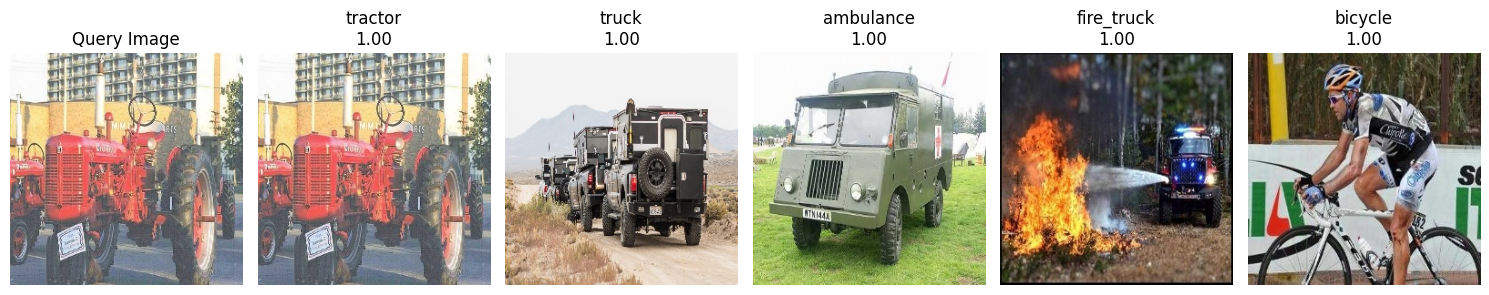

In [7]:
def display_results(query_image_path, results):
    plt.figure(figsize=(15, 4))

    # Show query image
    query_img = cv2.imread(query_image_path)
    query_img = cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(results) + 1, 1)
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis("off")

    # Show retrieved images
    for i, result in enumerate(results, start=2):
        img = cv2.imread(result["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(results) + 1, i)
        plt.imshow(img)
        plt.title(f"{result['label']}\n{result['score']:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

display_results(query_image, results)

## Precision@5 Evaluation

In [8]:
def precision_at_k(query_image_path, results, k=5):
    query_label = os.path.basename(os.path.dirname(query_image_path))
    correct = sum(1 for r in results[:k] if r["label"] == query_label)
    return correct / k

p_at_5 = precision_at_k(query_image, results, k=5)
print(f"Precision@5: {p_at_5:.2f}")

Precision@5: 0.20


## Test Another Category
GLCM usually works better on categories with strong texture patterns.
Examples:
- processed_dataset/buildings
- processed_dataset/mountains
- processed_dataset/elephants

Using query image: processed_dataset/bus\04d1869b-ad87-4838-a5f2-85c6ae329be0.jpg


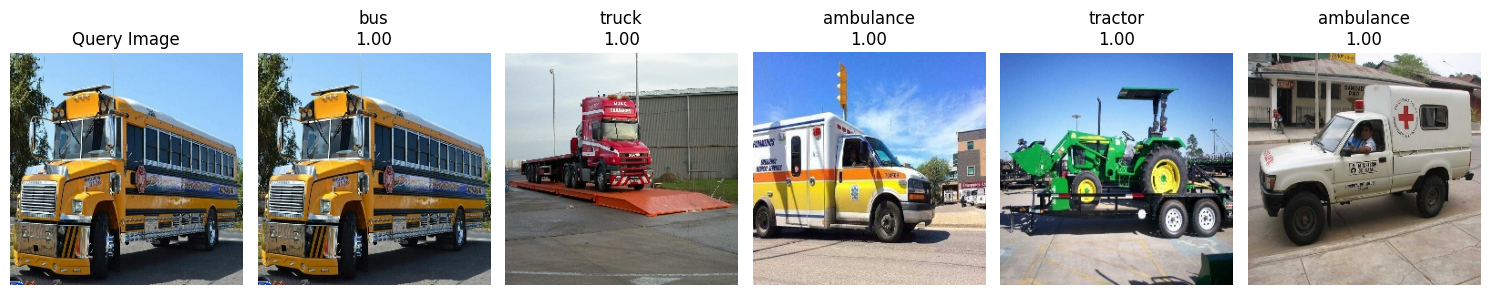

Precision@5: 0.20


In [9]:
category_path = "processed_dataset/bus"
img_name = os.listdir(category_path)[0]
query_image = os.path.join(category_path, img_name)

print("Using query image:", query_image)

results = retrieve_similar_images(query_image, top_k=5)
display_results(query_image, results)

p_at_5 = precision_at_k(query_image, results, k=5)
print(f"Precision@5: {p_at_5:.2f}")

## Summary

This notebook builds a CBIR system using GLCM texture features.

GLCM is useful for retrieving images based on surface texture and pixel relationships.
It is usually more effective for categories with rich texture information, such as:
- buildings
- mountains
- elephants

However, it may be weaker for categories that depend more on color than texture.